## Import libraries & set random seed

In [ ]:
import numpy as np
import pandas as pd
import os
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from PIL import Image
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
import warnings
import copy
warnings.filterwarnings('ignore')

manualSeed = 999
np.random.seed(manualSeed)
torch.manual_seed(manualSeed)
print("Random Seed:", manualSeed)

image_dir = '/kaggle/input/competitions/isic-2024-challenge/train-image/image'
meta_dir = "/kaggle/input/competitions/isic-2024-challenge/"
save_dir = '/kaggle/working/processed_images'
os.makedirs(save_dir, exist_ok=True)

image_files = os.listdir(image_dir)[:10]

for i, file_name in enumerate(image_files, 1):
    image_path = os.path.join(image_dir, file_name)
    with Image.open(image_path) as img:
        print(f"Image {i}: {file_name} - Size: {img.size}") 


Random Seed: 999
Image 1: ISIC_9730802.jpg - Size: (139, 139)
Image 2: ISIC_2834883.jpg - Size: (125, 125)
Image 3: ISIC_5115027.jpg - Size: (123, 123)
Image 4: ISIC_3264822.jpg - Size: (115, 115)
Image 5: ISIC_1950204.jpg - Size: (147, 147)
Image 6: ISIC_8411738.jpg - Size: (145, 145)
Image 7: ISIC_3744117.jpg - Size: (133, 133)
Image 8: ISIC_0989720.jpg - Size: (131, 131)
Image 9: ISIC_3926794.jpg - Size: (139, 139)
Image 10: ISIC_2892810.jpg - Size: (107, 107)


## Load CSV data & Create dataset 

In [ ]:
df = pd.read_csv(meta_dir + "train-metadata.csv")
print(f"Total dataset size: {len(df)}")
print(f"Target distribution:\n{df['target'].value_counts()}")

malignant_df = df[df["target"] == 1]
benign_df = df[df["target"] == 0].sample(n=10000, random_state=42)
df_filtered = pd.concat([malignant_df, benign_df]).reset_index(drop=True)

df_trainval, df_test = train_test_split(
    df_filtered,
    test_size=0.10,
    random_state=42,
    stratify=df_filtered['target']
)
df_trainval = df_trainval.reset_index(drop=True)
df_test     = df_test.reset_index(drop=True)

print(f"Train+Val : {len(df_trainval)}")
print(f"Test      : {len(df_test)}")
print(f"\nTrain+Val distribution:\n{df_trainval['target'].value_counts()}")
print(f"\nTest distribution:\n{df_test['target'].value_counts()}")

Total dataset size: 401059
Target distribution:
target
0    400666
1       393
Name: count, dtype: int64
Train+Val : 9353
Test      : 1040

Train+Val distribution:
target
0    8999
1     354
Name: count, dtype: int64

Test distribution:
target
0    1001
1      39
Name: count, dtype: int64


## DullRazor algorithm - hair removal functions

In [ ]:
def remove_hairs_dullrazor(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (9, 9))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, hair_mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
    hair_mask = cv2.dilate(hair_mask, np.ones((3, 3), np.uint8), iterations=1)
    inpainted = cv2.inpaint(img, hair_mask, inpaintRadius=1, flags=cv2.INPAINT_TELEA)
    return inpainted

## CLAHE contrast enhancement and data augmentation functions

In [ ]:
def apply_clahe_lab(img):
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2Lab)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_clahe = clahe.apply(l)
    lab_clahe = cv2.merge((l_clahe, a, b))
    img_clahe = cv2.cvtColor(lab_clahe, cv2.COLOR_Lab2RGB)
    return img_clahe

def augment_image(img):
    aug_imgs = []
    for angle in [90, 180, 270]:
        rotated = cv2.rotate(img, {
            90: cv2.ROTATE_90_CLOCKWISE,
            180: cv2.ROTATE_180,
            270: cv2.ROTATE_90_COUNTERCLOCKWISE
        }[angle])
        aug_imgs.append(rotated)
        aug_imgs.append(cv2.flip(rotated, 1))
    return aug_imgs

malignant_df = df[df["target"] == 1]
benign_df = df[df["target"] == 0].sample(n=10000, random_state=42)
df_filtered = pd.concat([malignant_df, benign_df]).reset_index(drop=True)

## Main preprocessing loop - processes all images

In [ ]:
new_records = []

for _, row in tqdm(df_filtered.iterrows(), total=len(df_filtered)):
    isic_id = row["isic_id"]
    label = row["target"]
    img_path = os.path.join(image_dir, f"{isic_id}.jpg")
    save_path = os.path.join(save_dir, f"{isic_id}.jpg")
    
    img = cv2.imread(img_path)
    if img is None:
        continue
    
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    
    img = remove_hairs_dullrazor(img)
    img = apply_clahe_lab(img)
    
    cv2.imwrite(save_path, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
    new_records.append({'isic_id': isic_id, 'target': label})

df_filtered_preprocessed = pd.DataFrame(new_records).reset_index(drop=True)

## Split data into Train / Val / Test (80/10/10)

In [ ]:
df_trainval, df_test = train_test_split(
    df_filtered_preprocessed,
    test_size=0.10,
    random_state=42,
    stratify=df_filtered_preprocessed['target']
)

df_train, df_val = train_test_split(
    df_trainval,
    test_size=0.111,
    stratify=df_trainval['target'],
    random_state=42
)

df_train    = df_train.reset_index(drop=True)
df_val      = df_val.reset_index(drop=True)
df_test     = df_test.reset_index(drop=True)
df_trainval = df_trainval.reset_index(drop=True)

## Define Dataset Class

In [ ]:
class SkinLesionDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        isic_id = self.df.iloc[idx]["isic_id"]
        label = self.df.iloc[idx]["target"]
        img_path = os.path.join(self.img_dir, f"{isic_id}.jpg")
        image = Image.open(img_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

## Define Resnet Model

In [9]:
from torchvision.models import resnet50, ResNet50_Weights

class ResNet50BinaryClassifier(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        weights = ResNet50_Weights.IMAGENET1K_V1 if pretrained else None
        self.backbone = resnet50(weights=weights)

        in_feats = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(in_feats, 1)
        )

    def forward(self, x):
        return self.backbone(x)

## Train and validate functions

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    preds_list, labels_list = [], []
    
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device).float().unsqueeze(1)
        
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * imgs.size(0)
        preds = torch.sigmoid(logits).detach().cpu().numpy() > 0.5
        preds_list.extend(preds.flatten())
        labels_list.extend(labels.cpu().numpy().flatten())
    
    avg_loss = running_loss / len(loader.dataset)
    acc = accuracy_score(labels_list, preds_list)
    return avg_loss, acc

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    preds_list, labels_list = [], []
    
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device).float().unsqueeze(1)
            logits = model(imgs)
            loss = criterion(logits, labels)
            running_loss += loss.item() * imgs.size(0)
            
            preds = torch.sigmoid(logits).cpu().numpy() > 0.5
            preds_list.extend(preds.flatten())
            labels_list.extend(labels.cpu().numpy().flatten())
    
    avg_loss = running_loss / len(loader.dataset)
    acc = accuracy_score(labels_list, preds_list)
    return avg_loss, acc

In [ ]:
EPOCHS_PER_FOLD = 10
BATCH_SIZE = 32
LEARNING_RATE = 2e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(299, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

## Full training loop - epochs, saves best model

In [ ]:
train_dataset = SkinLesionDataset(df_train, save_dir, transform=train_transform)
val_dataset   = SkinLesionDataset(df_val,   save_dir, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")

model = ResNet50BinaryClassifier(pretrained=True).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.8)
    
best_val_acc     = 0.0
best_model_state = None
val_acc_history  = []
train_acc_history = []

for epoch in range(EPOCHS_PER_FOLD):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss,   val_acc   = validate(model, val_loader, criterion, device)

    scheduler.step()
    val_acc_history.append(val_acc)
    train_acc_history.append(train_acc)

    print(f"Epoch {epoch+1}: "
          f"Train Loss = {train_loss:.4f}, Train Acc = {train_acc:.4f}, "
          f"Val Loss = {val_loss:.4f}, Val Acc = {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc     = val_acc
        best_model_state = copy.deepcopy(model.state_dict())

print(f"\nBest Val Accuracy: {best_val_acc:.4f}")

Train: 10201 | Val: 1274
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 184MB/s]


Epoch 1: Train Loss = 0.3568, Train Acc = 0.8471, Val Loss = 0.3294, Val Acc = 0.8548
Epoch 2: Train Loss = 0.3089, Train Acc = 0.8682, Val Loss = 0.2776, Val Acc = 0.8948
Epoch 3: Train Loss = 0.2960, Train Acc = 0.8744, Val Loss = 0.2928, Val Acc = 0.8713
Epoch 4: Train Loss = 0.2636, Train Acc = 0.8894, Val Loss = 0.2697, Val Acc = 0.8838
Epoch 5: Train Loss = 0.2533, Train Acc = 0.8897, Val Loss = 0.2815, Val Acc = 0.8925
Epoch 6: Train Loss = 0.2375, Train Acc = 0.9030, Val Loss = 0.2313, Val Acc = 0.9003
Epoch 7: Train Loss = 0.2113, Train Acc = 0.9119, Val Loss = 0.2243, Val Acc = 0.8956
Epoch 8: Train Loss = 0.1953, Train Acc = 0.9158, Val Loss = 0.2208, Val Acc = 0.9121
Epoch 9: Train Loss = 0.1854, Train Acc = 0.9223, Val Loss = 0.2177, Val Acc = 0.9121
Epoch 10: Train Loss = 0.1574, Train Acc = 0.9357, Val Loss = 0.1802, Val Acc = 0.9309

Best Val Accuracy: 0.9309


## Final evaluation on test set 

In [ ]:
model.load_state_dict(best_model_state)
model.eval()

test_dataset = SkinLesionDataset(df_test, save_dir, transform=val_transform)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

test_loss, test_acc = validate(model, test_loader, criterion, device)

print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test Loss     : {test_loss:.4f}")

Test Accuracy : 0.9475
Test Loss     : 0.1366


## Accuracy plot (Train vs Validation per epoch)

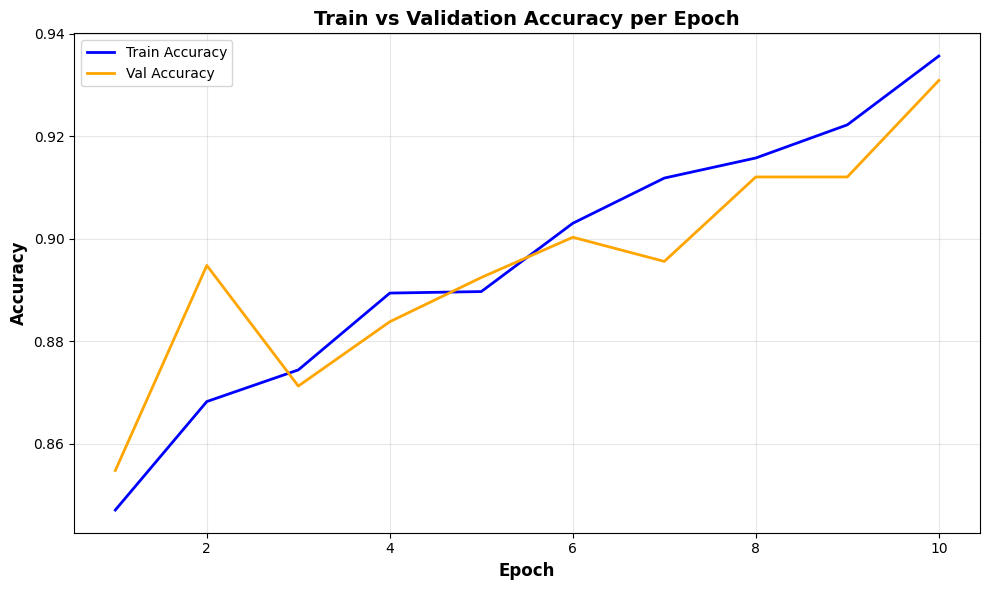

In [15]:
plt.figure(figsize=(10, 6))

plt.plot(range(1, len(train_acc_history) + 1),
         train_acc_history,
         color='blue', linewidth=2, label='Train Accuracy')

plt.plot(range(1, len(val_acc_history) + 1),
         val_acc_history,
         color='orange', linewidth=2, label='Val Accuracy')

plt.title("Train vs Validation Accuracy per Epoch", fontsize=14, fontweight='bold')
plt.xlabel("Epoch", fontsize=12, fontweight='bold')
plt.ylabel("Accuracy", fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()